<a href="https://colab.research.google.com/github/CreatorDave/201lab05a/blob/main/LAB7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from fractions import Fraction


You roll a fair six-sided die. What is the probability of rolling a 3 on the first roll and a 5 on the second roll? (Assume each roll is independent.)


In [6]:
# Probability of rolling a 3 on a fair six-sided die
p_first_roll = 1/6

# Probability of rolling a 5 on a fair six-sided die
p_second_roll = 1/6

# Combined probability (independent events)
combined_probability = p_first_roll * p_second_roll

# Print the result
print(f"The probability of rolling a 3 on the first roll and a 5 on the second roll is approximately: {combined_probability:.6f}")

p_total = Fraction(1, 6) * Fraction(1, 6)
print(p_total)

The probability of rolling a 3 on the first roll and a 5 on the second roll is approximately: 0.027778
1/36


You have a bag with six matches: three red marbles and three blue marbles. If you draw a marble, record its color, and then do not put it back into the  bag before drawing another marble. What is the probability of the following?

1. What is the probability of drawing a red marble on the first draw?
2. What is the probability of drawing a blue marble on the second draw after drawing a red marble on the first draw?
3. Calculate the probability of both events occurring (drawing a red marbble on the first draw and a blue marble on the second draw.)

In [9]:
#Preliminary thought process.

p_1 = Fraction(3, 6)  # Red First
p_2 = Fraction(3, 5)  # Blue second given red first
p_3 = Fraction(2, 4)  # Red third given red first & blue second

p_total = p_1 * p_2 * p_3
p_total

Fraction(3, 20)

In [17]:
# Refined with support and discussion.

import random

def trial():
  bag = ["R"]*3 + ["B"]*3
  random.shuffle(bag)

  first = bag.pop()
  second = bag.pop()
  third = bag.pop()

  return first == "R" and second == "B" and third == "R"

  N = 10000
  count = sum(trial() for _ in range(N))

  count / N


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.


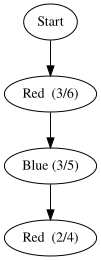

In [19]:
!apt-get install graphviz

from graphviz import Digraph

tree = Digraph()

tree.node("Start", "Start")
tree.node("R1", "Red  (3/6)")
tree.node("R2", "Blue (3/5)")
tree.node("R3", "Red  (2/4)")

tree.edge("Start", "R1")
tree.edge("R1", "R2")
tree.edge("R2", "R3")

tree

You flip a fair coin. What is the probability of getting heads or tails?

In [20]:
from fractions import Fraction

p_heads = Fraction(1, 2)
p_tails = Fraction(1, 2)

p_heads, p_tails

(Fraction(1, 2), Fraction(1, 2))

In a deck of 52 cards, what is the probability of drawing either a spade or face card (king, queen, jack)?

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.


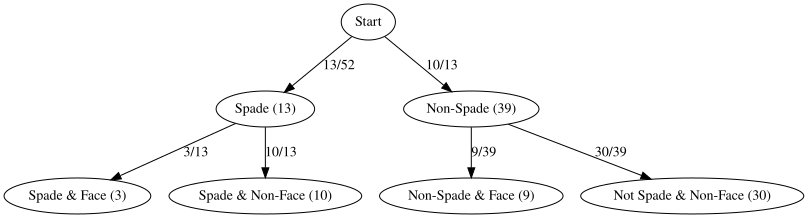

In [21]:
!apt-get install -y graphviz
!pip install graphviz

from graphviz import Digraph

tree = Digraph()

tree.node("Start", "Start")
tree.node("S", "Spade (13)")
tree.node("NS", "Non-Spade (39)")
tree.node("SF", "Spade & Face (3)")
tree.node("SNF", "Spade & Non-Face (10)")
tree.node("NSF", "Non-Spade & Face (9)")
tree.node("NSNF", "Not Spade & Non-Face (30)")

tree.edge("Start", "S", label="13/52")
tree.edge("Start", "NS", label="10/13")

tree.edge("S", "SF", label="3/13")
tree.edge("S", "SNF", label="10/13")

tree.edge("NS", "NSF", label="9/39")
tree.edge("NS", "NSNF", label="30/39")

tree



In [22]:
import random

# Build a deck: (suit, rank)
suits = ["♠", "♥", "♦", "♣"]
ranks = ["A", "2", "3", "4", "5", "6", "7", "8", "9", "10", "J", "Q", "K"]

deck = [(suit, rank) for suit in suits for rank in ranks]

def is_spade_or_face(card):
  suit, rank = card
  return suit == "♠" or rank in ["J", "Q", "K"]

N = 10000
count = 0

for _ in range(N):
  card = random.choice(deck)
  if is_spade_or_face(card):
    count += 1

sim_prob = count / N
sim_prob

0.4222

Answer the following and show your solution:
1. You roll a fair six-sided die. What is the probability of rolling a 3 on the first roll and a 5 on the
second roll? (Assume each roll is independent.)
2. You have a bag with six marbles: three red marbles and three blue marbles. If you draw a
marble, record its color, and then do not put it back into the bag before drawing another marble.
What is the probability of the following?
1. What is the probability of drawing a red marble on the first draw?
2. What is the probability of drawing a blue marble on the second draw after drawing a red
marble on the first draw?
3. Calculate the probability of both events occurring (drawing a red marble on the first draw
and a blue marble on the second draw).
3. You flip a fair coin. What is the probability of getting heads or tails?
4. In a deck of 52 cards, what is the probability of drawing either a spade or a face card (king,
queen, or jack)?